### Capstone Project: Book details

Provided dataset which was taken from Kaggle has information about various books with title, author, rating, no of ratings, no of reviews, description and genres. 

#### Index

- [Load and cleanup the data](#load-and-cleanup-the-data)
- [Visualizations of data](#visualizations-of-data)



In [284]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd # type: ignore
import seaborn as sns # type: ignore
from sklearn.datasets import fetch_openml # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge, RidgeClassifier
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


from sklearn.preprocessing import MultiLabelBinarizer # type: ignore


In [285]:
#!pip3 install seaborn

[Back to top](#index)
### Load and cleanup the data
Load the data and understand the various columns. Cleanup the data.



In [223]:
# Load dataset
# https://www.openml.org/search?type=data&status=active&id=43438
books = fetch_openml(data_id=43438, as_frame=True).frame
#books.to_csv('data/books_dataset.csv', index=False)

In [224]:
books.head(5)
books.info


<bound method DataFrame.info of              id                                              title                                               link              series                                         cover_link                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages     date_published                                publisher                                     original_title                                    genre_and_votes        isbn         isbn13 asin                                           settings                                         characters                                             awards                               amazon_redirect_link                             worldcat_redirect_link                                  recommended_books                               

In [225]:
missing_data = books.isnull().sum();
print(missing_data)

id                            0
title                       224
link                          0
series                    28880
cover_link                  607
author                        6
author_link                   0
rating_count                  0
review_count                  0
average_rating                0
five_star_ratings             0
four_star_ratings             0
three_star_ratings            0
two_star_ratings              0
one_star_ratings              0
number_of_pages            2330
date_published              860
publisher                  3935
original_title            13266
genre_and_votes            2840
isbn                      11883
isbn13                    12692
asin                      46963
settings                  40687
characters                38509
awards                    41574
amazon_redirect_link          0
worldcat_redirect_link     3985
recommended_books          3994
books_in_series           30121
description                2595
dtype: i

In [226]:
books = books.drop(columns=['id','cover_link','original_title','isbn','isbn13','asin','settings','characters', 'amazon_redirect_link', 'worldcat_redirect_link'])#,'recommended_books'])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
books.head(5)



,title,link,series,author,author_link,rating_count,review_count,average_rating,five_star_ratings,four_star_ratings,three_star_ratings,two_star_ratings,one_star_ratings,number_of_pages,date_published,publisher,genre_and_votes,awards,recommended_books,books_in_series,description
0,Inner Circle,https://www.goodreads.com//book/show/630104.In...,(Private 5),"Kate Brian, Julian Peploe",https://www.goodreads.com/author/show/94091.Ka...,7597,196,4.03,3045,2323,1748,389,92,220.0,January 1st 2007,Simon Schuster Books for Young Readers,"Young Adult 161, Mystery 45, Romance 32",NaN,"726458, 726458, 1537534, 3047848, 1651302, 304...","381489, 381501, 352428, 630103, 1783281, 17832...",Reed Brennan arrived at Easton Academy expecti...
1,A Time to Embrace,https://www.goodreads.com//book/show/9487.A_Ti...,(Timeless Love 2),Karen Kingsbury,https://www.goodreads.com/author/show/3159984....,4179,177,4.35,2255,1290,518,93,23,400.0,October 29th 2006,Thomas Nelson,"Christian Fiction 114, Christian 45, Fiction 3...",NaN,"127352, 127352, 40642197, 127353, 127354, 3891...",115036,"Ideje az lelsnek Trtnet a remnyrl, gygyulsrl, ..."
2,Take Two,https://www.goodreads.com//book/show/6050894-t...,(Above the Line 2),Karen Kingsbury,https://www.goodreads.com/author/show/3159984....,6288,218,4.23,3000,2020,1041,183,44,320.0,January 1st 2009,Zondervan,"Christian Fiction 174, Christian 81, Fiction 58",NaN,"706250, 706250, 666481, 11942636, 706241, 1273...","4010795, 40792877, 7306261",Filmmakers Chase Ryan and Keith Ellison have c...
3,Reliquary,https://www.goodreads.com//book/show/39030.Rel...,(Pendergast 2),"Douglas Preston, Lincoln Child",https://www.goodreads.com/author/show/12577.Do...,38382,1424,4.01,12711,15407,8511,1429,324,464.0,1997,Tor Books,"Thriller 626, Mystery 493, Horror 432, Fiction...",NaN,"39026, 39026, 11007668, 3986318, 51887330, 194...","67035, 39031, 39033, 136637, 136638, 30068, 39...",NaN
4,The Millionaire Next Door: The Surprising Secr...,https://www.goodreads.com//book/show/998.The_M...,NaN,"Thomas J. Stanley, William D. Danko",https://www.goodreads.com/author/show/659.Thom...,72168,3217,4.04,27594,25219,14855,3414,1086,258.0,October 28th 1995,Gallery Books,"Economics-Finance 1162, Nonfiction 910, Busine...",Independent Publisher Book Award (IPPY) Nomine...,"1052, 1052, 763362, 69571, 78427, 30186948, 10...",NaN,The incredible national bestseller that is cha...


In [227]:
#Checked if 'author' can be filled with 'author_link'. Link is not working most of the times
#rows_with_null_point = books[books['author'].isnull()]
#print(rows_with_null_point)
books = books.dropna(subset=['author'])

#Check if you can fill up 'title' from link. If not, drop it. NaN in 'title' books are in different language e.g. 'Urdu', 'Arabic', 'Greek'
#'title' with NaN as 224. Found 527 entries additinally with spaces as title. Those titles have different language. I will replace NaN with space
rows_with_null_point = books[books['title'].isnull()]
#print(rows_with_null_point)

books['title'] = books['title'].fillna(' ')
books.info




<bound method DataFrame.info of                                                    title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages     date_published                                publisher                                    genre_and_votes                                             awards                                  recommended_books                                    books_in_series                                        description
0                                           Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/94091.Ka...          7597           196            4.03           

In [228]:
missing_data = books.isnull().sum();
print(missing_data)

title                     0
link                      0
series                28875
author                    0
author_link               0
rating_count              0
review_count              0
average_rating            0
five_star_ratings         0
four_star_ratings         0
three_star_ratings        0
two_star_ratings          0
one_star_ratings          0
number_of_pages        2329
date_published          860
publisher              3932
genre_and_votes        2837
awards                41568
recommended_books      3993
books_in_series       30116
description            2592
dtype: int64


In [229]:
#books_cleaned = books.drop(columns=['link','author_link'], errors='ignore')
#books.to_csv('books_dataset_cleaned.csv', index=False)


In [230]:
count = (books['title'] == ' ').sum()
print(count)
# 527 + 224 = 751  
# We have double space as 'title' in 314 entries
#space_rows = books.index[books['title'] == '  '].tolist()
#print(space_rows)



751


In [231]:
space = '        '
count = (books['title'] == space).sum()
print(count)

print(books[books['title'] == space].head())
#3 spaces = 165, 4 spaces = 88, 5 spaces = 32, 6 spaces = 21, 7 spaces = 7, 8 spaces = 6

6
          title                                           link series              author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages    date_published publisher                                    genre_and_votes           awards                                  recommended_books books_in_series                                        description
3111              https://www.goodreads.com//book/show/6294481    NaN                        https://www.goodreads.com/author/show/2860197._          1095           113            4.42                685                251                 106                39                14            608.0  January 1st 1989            Religion 11, History 5, Religion-Islam 4, Nonf...              NaN  13565003, 13565003, 6280282, 545425, 11252250,...             NaN        :  (                  

In [232]:
# Replace any sequence of 1 or more spaces with exactly 1 space
books['title'] = books['title'].str.replace(r' +', ' ', regex=True)
space = ' '
count = (books['title'] == space).sum()
print(count)
#Count became 1389 from initial 527. We made all NaN as space and replaced all more than 1 spaces to 1 space as title.



1389


In [233]:
books.info


<bound method DataFrame.info of                                                    title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages     date_published                                publisher                                    genre_and_votes                                             awards                                  recommended_books                                    books_in_series                                        description
0                                           Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/94091.Ka...          7597           196            4.03           

In [234]:
space = '           '
count = (books['author'] == space).sum()
print(count)
#1 space = 515, 2 space=227, 3 space= 33, 4 space=8, 5 space=4, 6 space=0, 7 space=1, 8 space=1, 9 space=0, 10 space=1

0


In [235]:
books['author'] = books['author'].str.replace(r' +', ' ', regex=True)
space = ' '
count = (books['author'] == space).sum()
print(count)
#Count became 790 from initial 515. We made all NaN as space and replaced all more than 1 spaces to 1 space as title.


790


In [236]:
books['title'] = books['title'].replace(r'^\s*$', 'Other Title', regex=True)
books['author'] = books['author'].replace(r'^\s*$', 'Other Author', regex=True)

print(f"Titles that are just a space: {(books['title'] == ' ').sum()}")
print(f"Authors that are just a space: {(books['author'] == ' ').sum()}")

Titles that are just a space: 0
Authors that are just a space: 0


In [237]:
books['is_series'] = books['series'].notna().astype(int)
books['no_of_other_books_in_series'] = books['books_in_series'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)
books['award_count'] = books['awards'].fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)
books['year_published'] = pd.to_numeric(books['date_published'].str[-4:], errors='coerce').fillna(0).astype(int)

#This can be used as 'y' to predict
books['is_high_rated'] = (books['average_rating'] > 4.0).astype(int)

#We have a mismatch with data where books['series'] has data but books['books_in_series'] is empty. This code will fix that but not in original columns but in books['no_of_other_books_in_series']
books.loc[(books['is_series'] == True) & (books['no_of_other_books_in_series'] == 0), 'no_of_other_books_in_series'] = 1

books = books.drop(columns=['date_published'])

print(books.columns)

books.info


Index(['title', 'link', 'series', 'author', 'author_link', 'rating_count', 'review_count', 'average_rating', 'five_star_ratings', 'four_star_ratings', 'three_star_ratings', 'two_star_ratings', 'one_star_ratings', 'number_of_pages', 'publisher', 'genre_and_votes', 'awards', 'recommended_books', 'books_in_series', 'description', 'is_series', 'no_of_other_books_in_series', 'award_count', 'year_published', 'is_high_rated'], dtype='object')


<bound method DataFrame.info of                                                    title                                               link              series                                     author                                        author_link  rating_count  review_count  average_rating  five_star_ratings  four_star_ratings  three_star_ratings  two_star_ratings  one_star_ratings  number_of_pages                                publisher                                    genre_and_votes                                             awards                                  recommended_books                                    books_in_series                                        description  is_series  no_of_other_books_in_series  award_count  year_published  is_high_rated
0                                           Inner Circle  https://www.goodreads.com//book/show/630104.In...         (Private 5)                  Kate Brian, Julian Peploe  https://www.goodreads.com/author/show/9

In [238]:
#Trying to extract the main genre from books['genre_and_votes']. Filled up NaN with 'Other'. ThSplit with comma which will give first genre with votes. 
#Now as genre has spaces, we will use last space to take out votes. 
#For now I will ignore other genre in the field
books['genre_and_votes'] = books['genre_and_votes'].fillna('Other')
books['primary_genre'] = (
    books['genre_and_votes']
    .str.split(',')
    .str[0]
    .str.rsplit(' ', n=1)
    .str[0]
)

#List all the genre with counts. 'Other' will be in all the NaN 2837
genre_counts = books['primary_genre'].value_counts()
#print(genre_counts)
print(f"All the genres in books['primary_genre'] count: {len(genre_counts):,}")


All the genres in books['primary_genre'] count: 466


In [239]:
#Take out secondary_genre too. Split like books['primary_genre']. Fill all NaN with 'Other'. Make sure where books['primary_genre'] secondary_genre is too.
books['secondary_genre'] = (
    books['genre_and_votes']
    .str.split(',')
    .str[1]
    .str.strip()
    .str.rsplit(' ', n=1)
    .str[0]
)

books['secondary_genre'] = books['secondary_genre'].fillna('Other')

#If the primary was 'Other', the secondary should definitely be 'Other'
books.loc[books['primary_genre'] == 'Other', 'secondary_genre'] = 'Other'

print(books[['primary_genre', 'secondary_genre']].head(10))

           primary_genre                secondary_genre
0            Young Adult                        Mystery
1      Christian Fiction                      Christian
2      Christian Fiction                      Christian
3               Thriller                        Mystery
4      Economics-Finance                     Nonfiction
5                Romance  Historical-Historical Fiction
6                Romance  Historical-Historical Fiction
7                Fiction              American-Southern
8  Sequential Art-Comics  Sequential Art-Graphic Novels
9                 Poetry                      Childrens


In [240]:
#We can work with top 20(or 10) genres to start
top_20_genres = genre_counts.head(20)
print(top_20_genres)

remaining_books = len(books) - top_20_genres.sum()
remaining_percentage = (remaining_books / len(books)) * 100

#Check out Stats
print(f"Books covered by top 20 genres: {top_20_genres.sum():,}")
print(f"Books NOT covered: {remaining_books:,}")
print(f"Percentage of data not in top 20: {remaining_percentage:.2f}%")

primary_genre
Fiction                          6231
Fantasy                          5501
Romance                          3344
Young Adult                      3211
Other                            2837
Nonfiction                       2657
Historical-Historical Fiction    2266
Mystery                          1973
Science Fiction                  1447
Classics                         1172
History                          1051
Poetry                            973
Horror                            876
Fantasy-Paranormal                800
Childrens                         699
Sequential Art-Manga              679
Philosophy                        606
Thriller                          589
Fantasy-Urban Fantasy             537
Sequential Art-Comics             531
Name: count, dtype: int64
Books covered by top 20 genres: 37,980
Books NOT covered: 14,213
Percentage of data not in top 20: 27.23%


In [241]:
#Saving the books['primary_genre'] for further processing
genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

# Save to a file named 'genre_summary.csv'
genre_df.to_csv('data/primary_genre_summary.csv', index=False)

print("File saved as primary_genre_summary.csv")

File saved as primary_genre_summary.csv


In [242]:
#TODO: Use this data for modeling. 
#Genre cleaning by combining some genre in to one. Clean top 15 or 20 genres. Create a copy of the primary_genre column
books['genre_cleaned'] = books['primary_genre']

# Use .loc to find any genre that starts with or contains 'Young Adult'
# and set it exactly to 'Young Adult'
books.loc[books['genre_cleaned'].str.contains('Young Adult', na=False), 'genre_cleaned'] = 'Young Adult'
books.loc[books['genre_cleaned'].str.contains('Sequential Art', na=False), 'genre_cleaned'] = 'Sequential Art'
books.loc[books['genre_cleaned'].str.contains('Fantasy', na=False), 'genre_cleaned'] = 'Fantasy'
books.loc[books['genre_cleaned'].str.startswith('Mystery', na=False), 'genre_cleaned'] = 'Mystery'
books.loc[books['genre_cleaned'].str.startswith('Science Fiction', na=False), 'genre_cleaned'] = 'Science Fiction'
books.loc[books['genre_cleaned'].str.startswith('Romance', na=False), 'genre_cleaned'] = 'Romance'
books.loc[books['genre_cleaned'].str.startswith('Classics', na=False), 'genre_cleaned'] = 'Classics'
books.loc[books['genre_cleaned'].str.startswith('History', na=False), 'genre_cleaned'] = 'History'

books.loc[books['genre_cleaned'].str.startswith('Horror', na=False), 'genre_cleaned'] = 'Horror'
books.loc[books['genre_cleaned'].str.startswith('Childrens', na=False), 'genre_cleaned'] = 'Childrens'
books.loc[books['genre_cleaned'].str.startswith('Philosophy', na=False), 'genre_cleaned'] = 'Philosophy'
books.loc[books['genre_cleaned'].str.contains('Thriller', na=False), 'genre_cleaned'] = 'Thriller'
books.loc[books['genre_cleaned'].str.contains('Short Stories', na=False), 'genre_cleaned'] = 'Short Stories'
books.loc[books['genre_cleaned'].str.contains('Paranormal', na=False), 'genre_cleaned'] = 'Paranormal'

#Fiction?


# Verify the change
#print(books['genre_cleaned'].value_counts())

top_20_genres_cleaned = books['genre_cleaned'].value_counts().head(20)
print(top_20_genres_cleaned)
#With this change top 15(or 20) genres count change is added here
#Fantasy: 5501 —> 6991, Fiction: 6231, Romance: 3344 -> 4551, Young Adult: 3211 -> 3231, Other: 2837,Nonfiction: 2657, Historical-Historical Fiction: 2266, Mystery: 1973 -> 2121, Science Fiction: 1447 -> 1766, Sequential Art: 679 -> 1681, 
#Classics: 1172 -> 1176, History: 1051 —> 1057, Poetry: 973, Horror: 876 -> 996, Childrens: 699 -> 1293, Philosophy: 606 -> 610, Thriller: 589 -> 608, Short Stories: 511 -> 512, Christian Fiction: 457,Paranormal-Vampires: 439 -> 556



genre_cleaned
Fantasy                          6991
Fiction                          6231
Romance                          4551
Young Adult                      3231
Other                            2837
Nonfiction                       2657
Historical-Historical Fiction    2266
Mystery                          2121
Science Fiction                  1766
Sequential Art                   1681
Childrens                        1293
Classics                         1176
History                          1057
Horror                            996
Poetry                            973
Philosophy                        610
Thriller                          608
Paranormal                        556
Short Stories                     512
Christian Fiction                 457
Name: count, dtype: int64


In [243]:
#We can work with top 20(or 10) genres to start
genre_counts_cleaned = books['genre_cleaned'].value_counts()
#print (genre_counts_cleaned)
print(f"All the genres in books['primary_genre'] CLEANED count: {len(genre_counts_cleaned):,}")
#Unique Genres reduced to 388 from original 466
top_20_genres_cleaned = genre_counts_cleaned.head(20)
print(top_20_genres_cleaned)

remaining_books = len(books) - top_20_genres_cleaned.sum()
remaining_percentage = (remaining_books / len(books)) * 100

#Check out Stats
print(f"Books covered by top 20 genres: {top_20_genres_cleaned.sum():,}")
print(f"Books NOT covered: {remaining_books:,}")
print(f"Percentage of data not in top 20: {remaining_percentage:.2f}%")
#Now books which are NOT part of top 20 genres are reduced from ~27% to ~18%

All the genres in books['primary_genre'] CLEANED count: 388
genre_cleaned
Fantasy                          6991
Fiction                          6231
Romance                          4551
Young Adult                      3231
Other                            2837
Nonfiction                       2657
Historical-Historical Fiction    2266
Mystery                          2121
Science Fiction                  1766
Sequential Art                   1681
Childrens                        1293
Classics                         1176
History                          1057
Horror                            996
Poetry                            973
Philosophy                        610
Thriller                          608
Paranormal                        556
Short Stories                     512
Christian Fiction                 457
Name: count, dtype: int64
Books covered by top 20 genres: 42,570
Books NOT covered: 9,623
Percentage of data not in top 20: 18.44%


In [244]:
books['publisher'] = books['publisher'].replace(r'^\s*$', 'Other', regex=True)
books['publisher'] = books['publisher'].fillna('Other')


In [245]:
#See the specific genres that fell outside the top 20:
#Checking this so it can be used to combine some genre together. e.g. Romantic Suspense, Romance-M M Romance as 'Romance'
print(genre_counts.iloc[20:40])

primary_genre
Short Stories                    511
Sequential Art-Graphic Novels    457
Christian Fiction                457
Paranormal-Vampires              439
Biography                        426
Novels                           417
Childrens-Picture Books          380
Romance-Historical Romance       372
Romance-Paranormal Romance       356
Christian                        319
Womens Fiction-Chick Lit         319
New Adult                        313
Science                          304
Religion                         294
Romance-M M Romance              282
Humor                            253
Plays                            242
Self Help                        219
Psychology                       215
Childrens-Middle Grade           204
Name: count, dtype: int64


In [246]:
#books.to_csv('data/books_dataset_cleaned.csv', index=False)

[Back to top](#index)
### Visualizations of data
Visualisation of the data with various charts


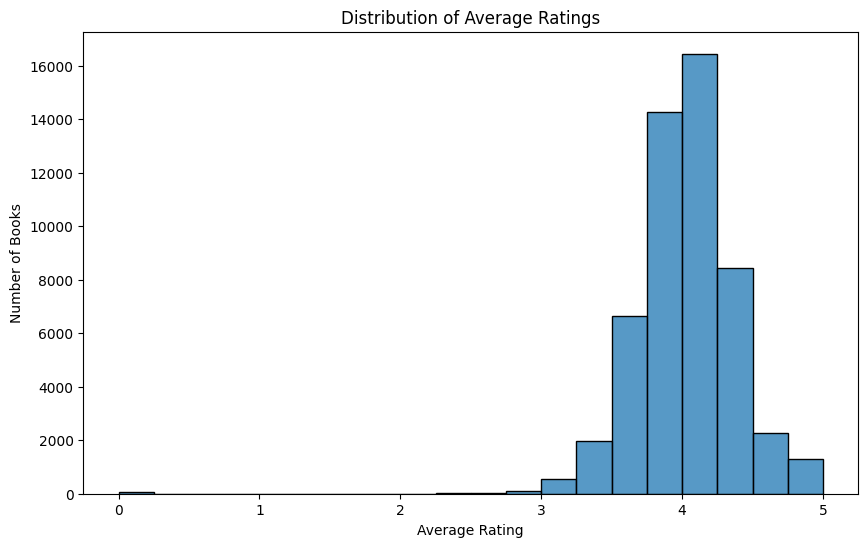

In [247]:
#Average Ratings
plt.figure(figsize=(10, 6))
sns.histplot(books['average_rating'], bins=20)
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.savefig('images/rating_dist.png')

                         author  count
0                  Nora Roberts     87
1               Agatha Christie     74
2                  Stephen King     66
3                   Erin Hunter     57
4                     Meg Cabot     55
5                 Bella Forrest     53
6                   Lucian Bane     49
7               Karen Kingsbury     49
8               Terry Pratchett     48
9               Mercedes Lackey     47
10                Bonnie Bryant     47
11             Sherrilyn Kenyon     45
12                  Enid Blyton     45
13  Will Durant, Ariel Durant,      44
14                Carolyn Keene     43


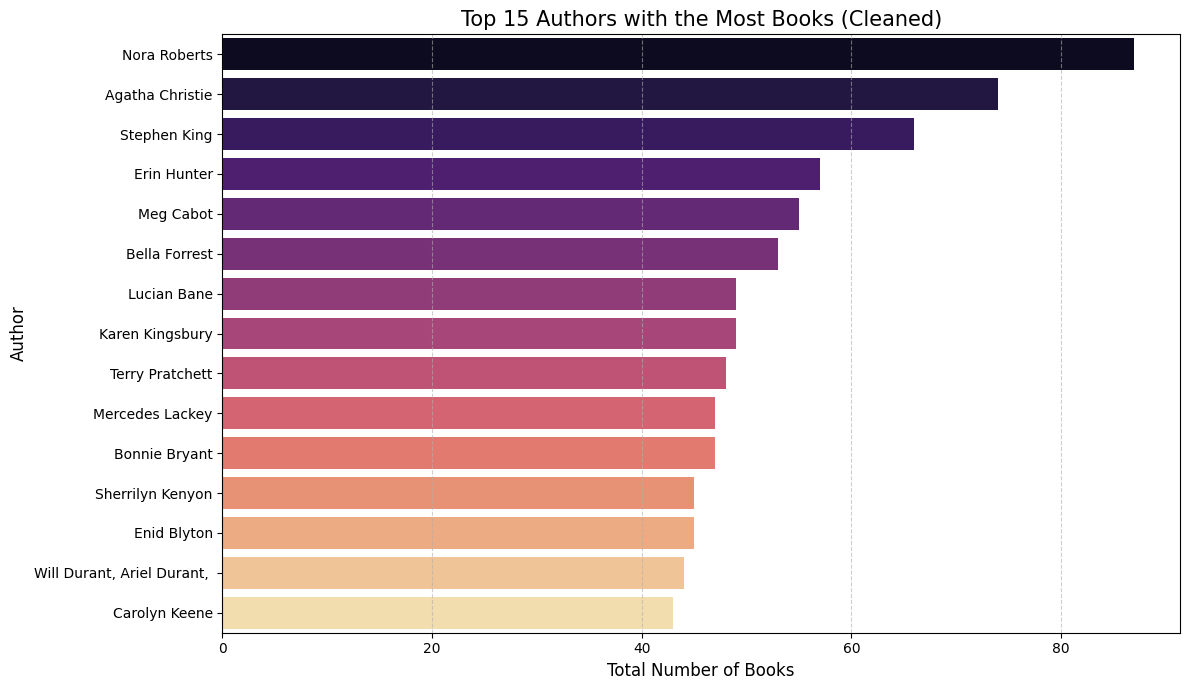

In [248]:

#I saw lot of authors has space as value.  Filter those out. 
#That analysis has been added in one of the previous code cell.

#Just filtering spaces I saw that comma is also one of the author in the list so I am ignoring that too.
#'NOT A BOOK' is usually some articles 
#clean_books = books[books['author'].str.strip() != "" ]
#clean_books = books[(books['author'].str.strip() != "") & (books['author'].str.strip() != ",")]

invalid_authors = ["", " ", ",", "Other Author","NOT A BOOK"]
clean_books = books[~books['author'].str.strip().isin(invalid_authors)]

top_prolific_authors = clean_books['author'].value_counts().head(15).reset_index()
print (top_prolific_authors)
top_prolific_authors.columns = ['author', 'book_count']

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_prolific_authors, 
    x='book_count', 
    y='author', 
    palette='magma',
    hue='author',
    legend=False
)

plt.title('Top 15 Authors with the Most Books (Cleaned)', fontsize=15)
plt.xlabel('Total Number of Books', fontsize=12)
plt.ylabel('Author', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

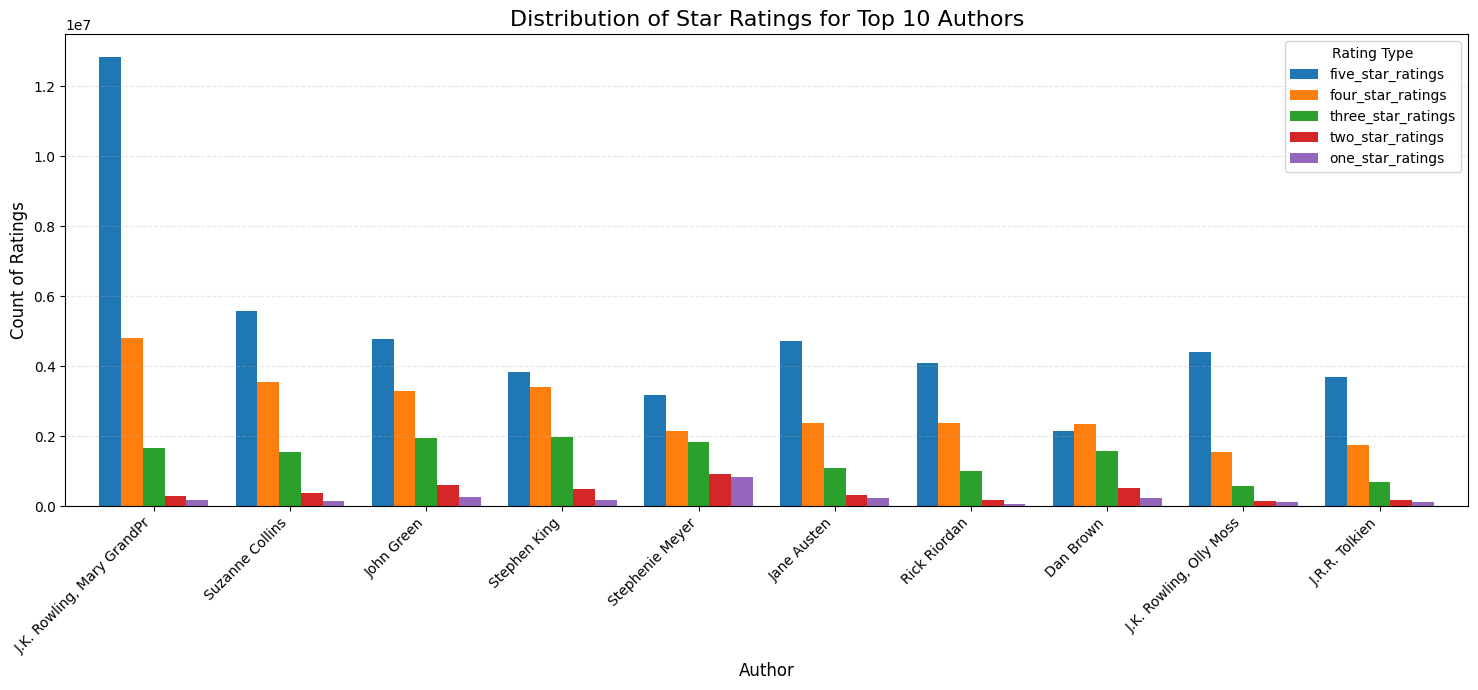

In [249]:
#Top 10 authors star distibution
#We can see 'J K Rowling' is here twice for 'Harry Potter' series for diffent editions with it's atrist. 
star_cols = ['five_star_ratings', 'four_star_ratings', 'three_star_ratings', 'two_star_ratings', 'one_star_ratings']
author_stars = books.groupby('author')[star_cols].sum()

top_10_authors = books.groupby('author')['rating_count'].sum().nlargest(10).index
plot_data = author_stars.loc[top_10_authors]

ax = plot_data.plot(kind='bar', figsize=(15, 7), width=0.8)

plt.title('Distribution of Star Ratings for Top 10 Authors', fontsize=16)
plt.ylabel('Count of Ratings', fontsize=12)
plt.xlabel('Author', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Rating Type")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

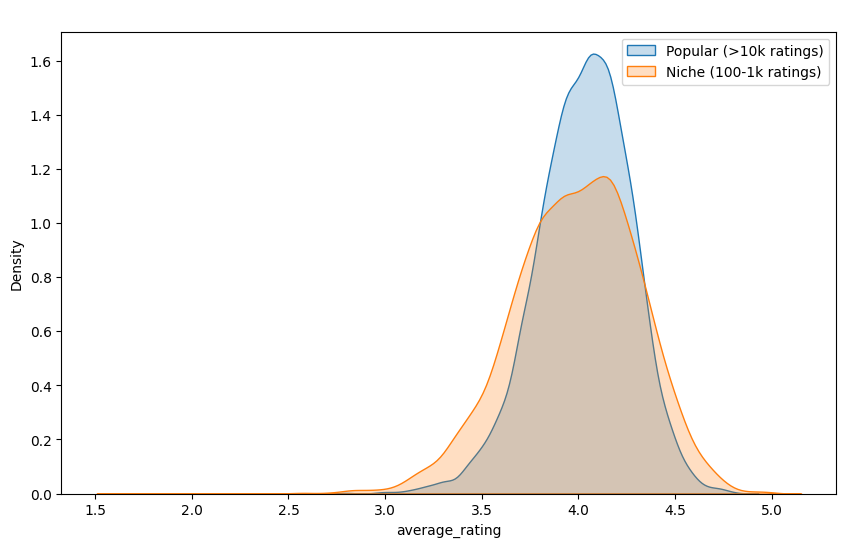

In [250]:
#Popular books vs niche books
popular = books[books['rating_count'] > 10000]['average_rating']
niche = books[(books['rating_count'] > 100) & (books['rating_count'] <= 1000)]['average_rating']

plt.figure(figsize=(10, 6))
sns.kdeplot(popular, label='Popular (>10k ratings)', fill=True)
sns.kdeplot(niche, label='Niche (100-1k ratings)', fill=True)
plt.title(' ')
plt.legend()
plt.show()

publisher
Vintage                                        572
HarperCollins                                  562
Penguin Books                                  502
Ballantine Books                               396
Bantam                                         374
Createspace Independent Publishing Platform    368
Pocket Books                                   318
Avon                                           307
Simon  Schuster                                300
Del Rey                                        287
Name: count, dtype: int64


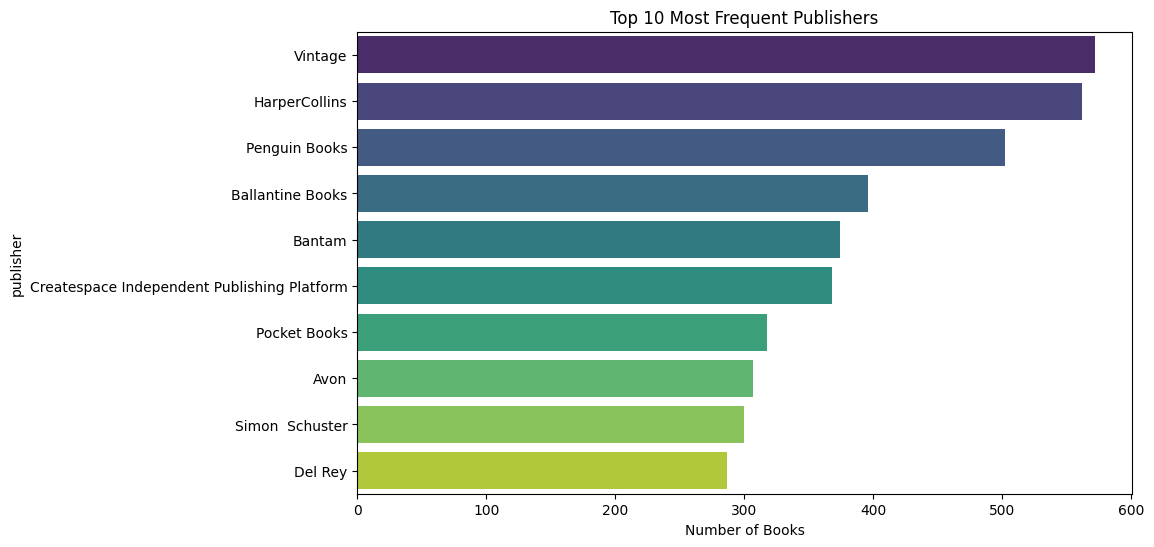

In [251]:

#Top 10 frequent Publishers. Ignoring others as it comes as top publisher as in clean up we replaced all spaces and NaN with 'Other'
filtered_publishers = books[books['publisher'] != 'Other']['publisher']
top_publishers = filtered_publishers.value_counts().nlargest(10)
print (top_publishers)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, hue=top_publishers.index, palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Publishers')
plt.xlabel('Number of Books')
plt.show()


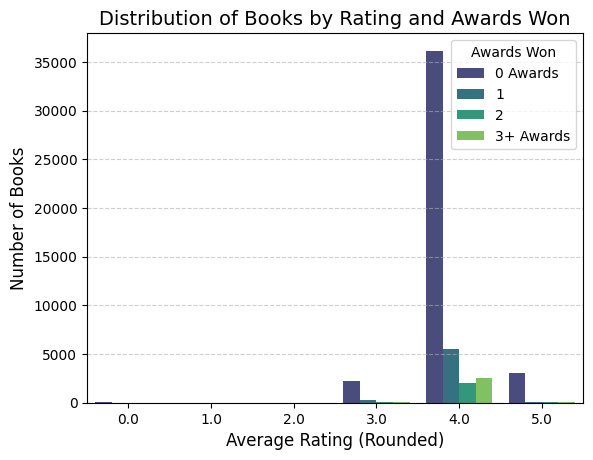

In [252]:
rating_bins = books['average_rating'].round()
award_groups = books['award_count'].apply(lambda x: '0 Awards' if x == 0 else (str(x) if x < 3 else '3+ Awards'))
sns.countplot(
    x=rating_bins, 
    hue=award_groups, 
    hue_order=['0 Awards', '1', '2', '3+ Awards'],
    palette='viridis'
)
plt.title('Distribution of Books by Rating and Awards Won', fontsize=14)
plt.xlabel('Average Rating (Rounded)', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.legend(title='Awards Won')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


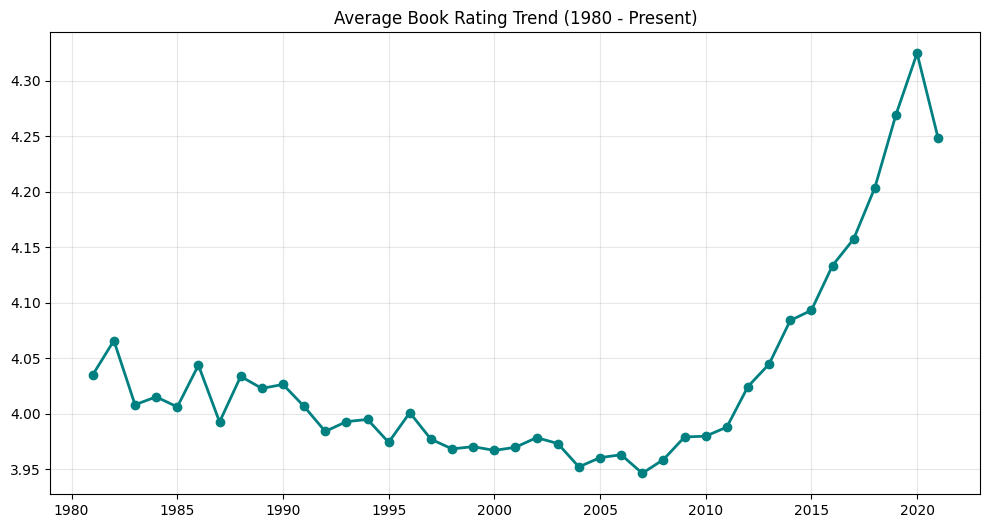

In [253]:
#Rating Trend Over Time (Since 1980). We will us the column which we added 'year_published'
plt.figure(figsize=(12, 6))
yearly_trend = books[books['year_published'] > 1980].groupby('year_published')['average_rating'].mean()
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', color='teal', linewidth=2)
plt.title('Average Book Rating Trend (1980 - Present)')
plt.grid(True, alpha=0.3)

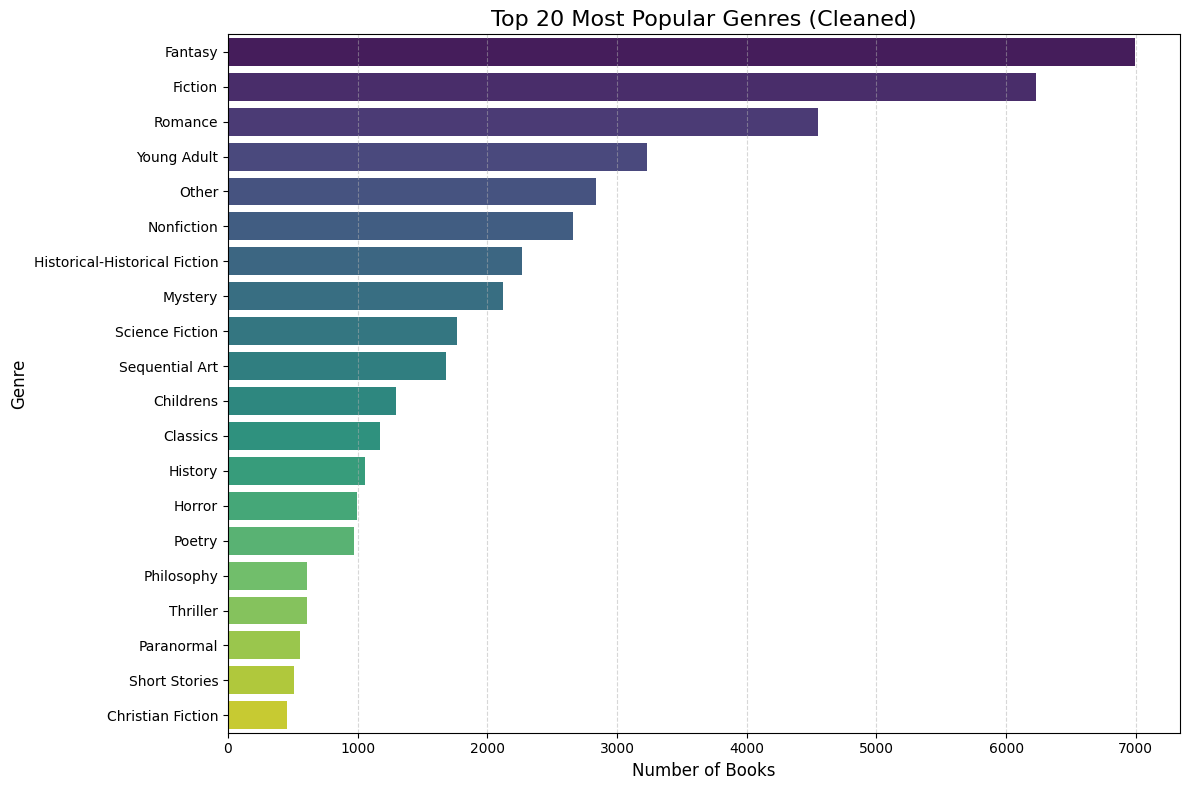

In [254]:
#No of books for top 20 genre
top_genres = books['genre_cleaned'].value_counts().head(20).reset_index()
top_genres.columns = ['genre', 'count']

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_genres, 
    x='count', 
    y='genre', 
    palette='viridis', 
    hue='genre', 
    legend=False
)

plt.title('Top 20 Most Popular Genres (Cleaned)', fontsize=16)
plt.xlabel('Number of Books', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Metric                         | Original     | Cleaned     
------------------------------------------------------------
Total Books in Dataset         | 52193        | 52193       
Books in Top 20 Genres         | 37980        | 42570       
% Covered by Top 20            | 72.77%      | 81.56%
------------------------------------------------------------


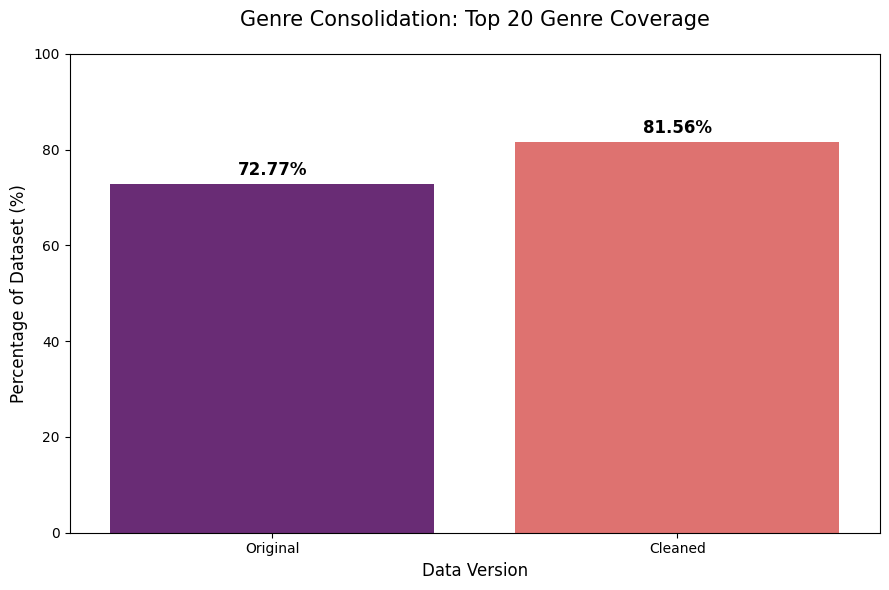

In [255]:
#I have similar comparison done manually in previous cells
total_books = len(books)

def get_top_20_stats(column_name):
    counts = books[column_name].value_counts()
    top_20_count = counts.head(20).sum()
    percentage = (top_20_count / total_books) * 100
    return top_20_count, percentage

count_orig, perc_orig = get_top_20_stats('primary_genre')
count_clean, perc_clean = get_top_20_stats('genre_cleaned')

print(f"\n{'Metric':<30} | {'Original':<12} | {'Cleaned':<12}")
print("-" * 60)
print(f"{'Total Books in Dataset':<30} | {total_books:<12} | {total_books:<12}")
print(f"{'Books in Top 20 Genres':<30} | {count_orig:<12} | {count_clean:<12}")
print(f"{'% Covered by Top 20':<30} | {perc_orig:.2f}%      | {perc_clean:.2f}%")
print("-" * 60)

comparison_df = pd.DataFrame({
    'Version': ['Original', 'Cleaned'],
    'Coverage %': [perc_orig, perc_clean]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    x='Version', 
    y='Coverage %', 
    data=comparison_df, 
    palette='magma', 
    hue='Version', 
    legend=False
)

plt.ylim(0, 100)
plt.title('Genre Consolidation: Top 20 Genre Coverage', fontsize=15, pad=20)
plt.ylabel('Percentage of Dataset (%)', fontsize=12)
plt.xlabel('Data Version', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Total rows in dataset: 52193
Rows found for Top 20 Genres: 40159
Series vs Standalone counts:
series_label
Series        20697
Standalone    19462
Name: count, dtype: int64


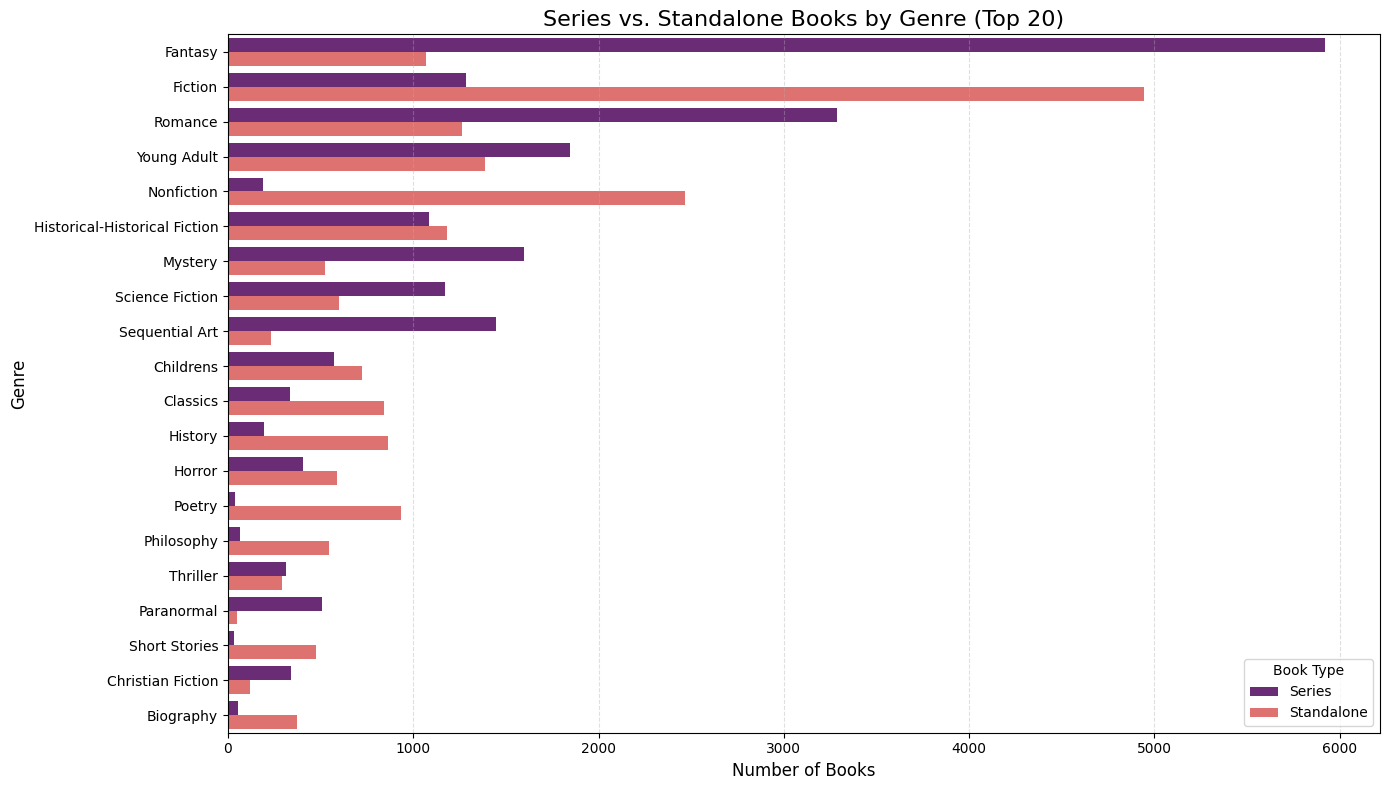

In [256]:
# 1. FORCE data types to be strings to avoid matching errors
books['genre_cleaned'] = books['genre_cleaned'].astype(str).str.strip()

# 2. FORCE is_series to be a string label directly to avoid mapping errors
# We check for both boolean and string versions of True/1
books['series_label'] = books['is_series'].apply(
    lambda x: 'Series' if str(x).lower() in ['true', '1', '1.0'] else 'Standalone'
)

# 3. Get the top 20 genres (excluding anything that looks like NaN/Empty)
genre_counts = books['genre_cleaned'].value_counts()
# Filter out common null-like strings
top_20_genres = [g for g in genre_counts.index if g.lower() not in ['nan', 'none', '', 'other']][:20]

# 4. DIAGNOSTIC PRINT: If these are 0, we know the problem is in the filtering
plot_data = books[books['genre_cleaned'].isin(top_20_genres)].copy()
print(f"Total rows in dataset: {len(books)}")
print(f"Rows found for Top 20 Genres: {len(plot_data)}")
print(f"Series vs Standalone counts:\n{plot_data['series_label'].value_counts()}")

if len(plot_data) == 0:
    print("!!! STOP: No data found for the graph. Check if 'genre_cleaned' exists and has values.")
else:
    plt.figure(figsize=(14, 8))
    
    # Use the 'hue' parameter inside countplot
    sns.countplot(
        data=plot_data,
        y='genre_cleaned',
        hue='series_label', 
        order=top_20_genres,
        palette='magma'
    )

    plt.title('Series vs. Standalone Books by Genre (Top 20)', fontsize=16)
    plt.xlabel('Number of Books', fontsize=12)
    plt.ylabel('Genre', fontsize=12)
    plt.legend(title='Book Type', loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

[Back to top](#-Index)

### Modeling

Predict the success of the book by using few meaningful features. Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [257]:
print(books.info())


<class 'pandas.core.frame.DataFrame'>
Index: 52193 entries, 0 to 52198
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        52193 non-null  object 
 1   link                         52193 non-null  object 
 2   series                       23318 non-null  object 
 3   author                       52193 non-null  object 
 4   author_link                  52193 non-null  object 
 5   rating_count                 52193 non-null  int64  
 6   review_count                 52193 non-null  int64  
 7   average_rating               52193 non-null  float64
 8   five_star_ratings            52193 non-null  int64  
 9   four_star_ratings            52193 non-null  int64  
 10  three_star_ratings           52193 non-null  int64  
 11  two_star_ratings             52193 non-null  int64  
 12  one_star_ratings             52193 non-null  int64  
 13  number_of_pages      

In [258]:
#Grouping the authors who has less number of books to reduce the variation in number of authors. 
author_counts = books['author'].value_counts() 
top_authors = author_counts[author_counts >= 10].index #
books['author_grouped'] = books['author'].apply(lambda x: x if x in top_authors else 'Other Author')
percentage_covered = (author_counts[author_counts >= 10].sum() / len(books)) * 100
print(f"Books written by authors with 10+ books: {author_counts[author_counts >= 10].sum()}")
print(f"Percentage of data covered: {percentage_covered:.2f}%")
#We have author_counts = 27226 
#top_authors = 581
#print (top_authors)
#If we change 10 books to 5 36% of data is covered

#Grouping the publisher who has less number of books to reduce the variation in number of authors. 
pub_counts = books['publisher'].value_counts()
top_pubs = pub_counts[pub_counts >= 20].index
books['publisher_grouped'] = books['publisher'].apply(lambda x: x if x in top_pubs else 'Other Publisher')
percentage_covered = (pub_counts[pub_counts >= 10].sum() / len(books)) * 100
print(f"Books written by authors with 10+ books: {pub_counts[pub_counts >= 10].sum()}")
print(f"Percentage of data covered: {percentage_covered:.2f}%")

#We have pub_counts = 10359 
#top_pubs = 377


Books written by authors with 10+ books: 10860
Percentage of data covered: 20.81%
Books written by authors with 10+ books: 35802
Percentage of data covered: 68.60%


In [259]:
#Without star_rating columns
#books_model_1_col = ['author','rating_count','review_count','is_series','no_of_other_books_in_series']
#books_model_1_col = ['author','publisher','primary_genre','rating_count','review_count','is_series','no_of_other_books_in_series']
#books_model_1_col = ['author_grouped','publisher_grouped','primary_genre','rating_count','review_count','is_series','no_of_other_books_in_series']
#Without any ratings info
#books_model_1_col = ['author','publisher','primary_genre','is_series','no_of_other_books_in_series']

books_model_1_col = ['author','publisher','primary_genre','is_series','no_of_other_books_in_series','year_published']

books_model_X_1 = books[books_model_1_col].copy()
y_1 = books['is_high_rated']


X_train, X_test, y_train, y_test = train_test_split(books_model_X_1, y_1, test_size=0.3, random_state=22)

categorical_columns = books_model_X_1.select_dtypes(include=['object']).columns.tolist()
numerical_columns = books_model_X_1.select_dtypes(include=['float64', 'int64']).columns.tolist()
print (categorical_columns)
print (numerical_columns)


['author', 'publisher', 'primary_genre']
['is_series', 'no_of_other_books_in_series', 'year_published']


Accuracy: 0.7074338996040362
[[5033 2270]
 [2311 6044]]


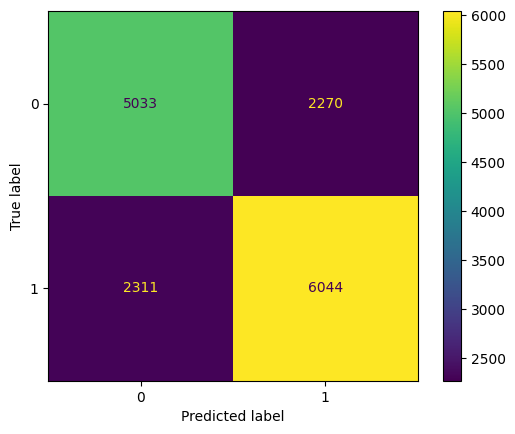

In [260]:
processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

lg_eco = Pipeline([
    ('prep', processor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'))
])
lg_eco.fit(X_train, y_train)
y_pred = lg_eco.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print (f"Accuracy: {accuracy}")
print (conf_matrix)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot()

#This model's accuracy is around 70.8%. 
#Here we built a model which uses book's metadata like author, publisher, genre, year of publishing, part of series and no of books in the series to predict whether book will be rated high or not

#I tried all the commented columns dataset from previous cell of code with same model above and I am always getting results ~70% meaning with provided columns the model has converged and now stable. 
#We need to use some other columns and models to come up with better results. But even the current model can be used by marketing/sales team to predict and target which books to market more on and can have higher sales

In [261]:
#Now apply all other models and compare with this new dataset

#Comparision with adding some parameters in models. Passing mainly balanced data
models_param = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'),
    "KNN": KNeighborsClassifier(weights='distance'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Ridge": RidgeClassifier(class_weight='balanced', random_state=42, solver='sag', alpha=20.0, fit_intercept=False),
    #"SVM": SVC(class_weight='balanced', random_state=42)
}

results = []
for name, model in models_param.items():
    pipe = Pipeline([
        ('processor', processor),
        ('model', model)
    ])
    
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()

    fit_time = end_time - start_time
    # Evaluate on training and test sets
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    

    results.append([name, fit_time, train_score, test_score])

results_df = pd.DataFrame(results, columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy'])
results_df.set_index('Model', inplace=True)

print (results_df)


                     Train Time  Train Accuracy  Test Accuracy
Model                                                         
Logistic Regression    0.558313        0.861776       0.707434
KNN                    0.063101        0.993951       0.690446
Decision Tree          1.684918        0.994033       0.674990
Ridge                  0.131064        0.755905       0.687636


In [262]:
#Add additional hyperpapameter and compare the results.
# Define models and their hyperparameters
models_hyperparameters = {
    "logisticregression": (LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'), {'logisticregression__C': [0.1, 1, 10]}),
    "knn": (KNeighborsClassifier(weights='distance'), {'knn__n_neighbors': [3, 5, 7, 11]}),
    "decisiontree": (DecisionTreeClassifier(class_weight='balanced', random_state=42), {'decisiontree__max_depth': [5, 10, 15]}),
    "ridge": (RidgeClassifier(class_weight='balanced', random_state=42, solver='sag', fit_intercept=False), {'ridge__alpha': [1.0, 10.0, 20.0, 50.0]}),
    #"svc": (SVC(class_weight='balanced', random_state=42), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
}


results = []

# Train and evaluate each model
for name, (model, params) in models_hyperparameters.items():
    # Create a pipeline with StandardScaler and the model
    pipeline = Pipeline([
        ('processor', processor),
        (name, model)
    ])
    pipeline
    
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, scoring='f1_weighted', n_jobs=-1)
    
    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_model = grid_search.best_estimator_
    
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    
    # Append the results
    results.append([name, grid_search.best_params_, fit_time, train_score, test_score])

    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print (cm)
    #disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    #disp.plot()
    
# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Best Params', 'Average Train Time', 'Train Accuracy', 'Test Accuracy'])
results_df.set_index('Model', inplace=True)

# Display the DataFrame
print(results_df)


Python(93340) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93345) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93347) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93349) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93350) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93352) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93354) Malloc

[[5033 2270]
 [2311 6044]]
[[4861 2442]
 [2376 5979]]
[[4743 2560]
 [2897 5458]]
[[4952 2351]
 [2310 6045]]
                                        Best Params  Average Train Time  Train Accuracy  Test Accuracy
Model                                                                                                 
logisticregression     {'logisticregression__C': 1}            1.527077        0.861776       0.707434
knn                        {'knn__n_neighbors': 11}           25.182811        0.994033       0.692298
decisiontree        {'decisiontree__max_depth': 15}            0.290657        0.684111       0.651488
ridge                         {'ridge__alpha': 1.0}            0.392329        0.925523       0.702325


[Back to top](#-Index)

### Modeling - secondary genre with 30% weightage

 Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [263]:
#Adding 'secondary_genre' also as one the feature
sec_genre_cols_to_use = ['author', 'publisher', 'primary_genre', 'secondary_genre', 'is_series', 'no_of_other_books_in_series', 'year_published']

X = books[sec_genre_cols_to_use].copy()
y = books['is_high_rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22)

#30% weightage
def weight_30(X):
    return X * 0.3

processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['no_of_other_books_in_series', 'year_published']),
        ('cat_primary', OneHotEncoder(handle_unknown='ignore'), ['author', 'publisher', 'primary_genre', 'is_series']),
        ('cat_secondary', Pipeline([
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ('scale', FunctionTransformer(weight_30, accept_sparse=True))
        ]), ['secondary_genre'])
    ],
    remainder='drop'
)

lg_eco_weighted = Pipeline([
    ('prep', processor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'))
])
lg_eco_weighted.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_other_books_in_series',
                                                   'year_published']),
                                                 ('cat_primary',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['author', 'publisher',
                                                   'primary_genre',
                                                   'is_series']),
                                                 ('cat_secondary',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore')),
                                                                  ('scale',
                                                                   FunctionTransformer(accept_sparse=True,
                                                                                       func=<function weight_30 at 0x31d5ccee0>))]),
                                                  ['secondary_genre'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42, solver='saga'))])

New Accuracy with Weighted Secondary Genre: 0.7119
[[5085 2218]
 [2293 6062]]


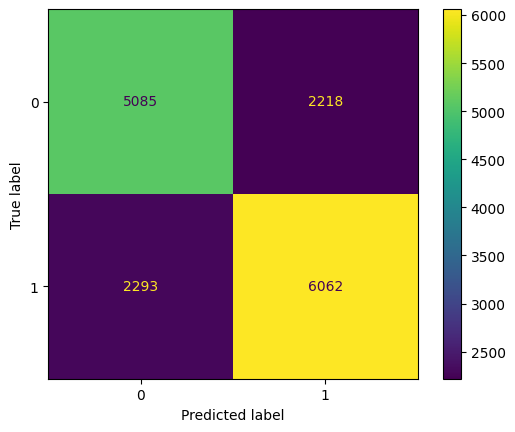

In [264]:
y_pred = lg_eco_weighted.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"New Accuracy with Weighted Secondary Genre: {accuracy:.4f}")
print(conf_matrix)
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot()

#We see minor improvement. We can try out various % weightage like 40%, 50% for 'secondary_genre' column. We can also try grid_search by passing few options. 
#Suggestion of using weightage for 'secondary_genre' column was suggested by Jessica in our 1 on 1 session. 

[Back to top](#-Index)

### Modeling - genre_cleaned

 Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [265]:
books_model_genre_cleaned_col = ['author','publisher','genre_cleaned','is_series','no_of_other_books_in_series','year_published']

books_model_X_genre_cleaned = books[books_model_genre_cleaned_col].copy()
y_1 = books['is_high_rated']


X_train, X_test, y_train, y_test = train_test_split(books_model_X_genre_cleaned, y_1, test_size=0.3, random_state=22)

categorical_columns = books_model_X_genre_cleaned.select_dtypes(include=['object']).columns.tolist()
numerical_columns = books_model_X_genre_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

Accuracy: 0.7075616298377826
[[5024 2279]
 [2300 6055]]


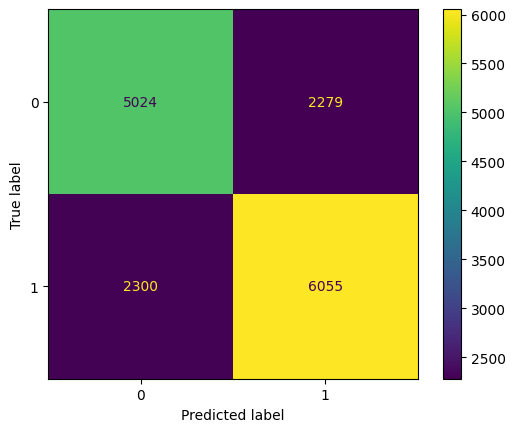

In [266]:
processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

lg_eco = Pipeline([
    ('prep', processor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=3000, solver='saga'))
])
lg_eco.fit(X_train, y_train)
y_pred = lg_eco.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print (f"Accuracy: {accuracy}")
print (conf_matrix)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot()

#With genre_cleaned we get accuracy of 70.73. Not much change from original usage of primary_genre

[Back to top](#-Index)

### Modeling - Natural Language Processing (NLP)

 Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [267]:
train_books = books[(books['primary_genre'] != 'Other') & (books['description'].notna())]
predict_books = books[books['primary_genre'] == 'Other']
#X has books where books['primary_genre'] is not Other and books['description'] not null
X = train_books['description']
y = train_books['primary_genre']
print(f"Total books where primary_genre is NOT 'Other' and description is NOT NaN: {len(X)}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Total books where primary_genre is NOT 'Other' and description is NOT NaN: 47119


In [268]:
def run_experiment(vectorizer_type, ngram_range, C_val):
    if vectorizer_type == 'count':
        vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, max_features=5000)
    else:
        vec = TfidfVectorizer(stop_words='english', ngram_range=ngram_range, max_features=5000)
    
    pipeline = Pipeline([
        ('vectorizer', vec),
        ('classifier', LogisticRegression(C=C_val, max_iter=1000))
    ])
    
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    return score

# Example Tests
print(f"Count + (1,1) + C=1.0: {run_experiment('count', (1,1), 1.0):.4f}")
print(f"TF-IDF + (1,1) + C=1.0: {run_experiment('tfidf', (1,1), 1.0):.4f}")
print(f"TF-IDF + (1,2) + C=0.1:  {run_experiment('tfidf', (1,2), 0.1):.4f}")

Count + (1,1) + C=1.0: 0.3889
TF-IDF + (1,1) + C=1.0: 0.4252
TF-IDF + (1,2) + C=0.1:  0.3110


In [269]:
#Above code is taking long time to process as we have a lot of variation of primary_genre. We can narrow down that but focusing on top 20 genres
#Get Top 20 Genres (excluding 'Other')
top_20_genres = train_books['genre_cleaned'].value_counts().nlargest(20).index

#print (train_books['genre_cleaned'].value_counts()) #This is 376. Originally genre_cleaned had 388 unique values. We have some books with genres where description is NaN

#Take out books which only includes these 20 categories
train_books_top20 = train_books[train_books['genre_cleaned'].isin(top_20_genres)]

print(f"Original training size: {len(train_books)}")
print(f"Top 20 training size: {len(train_books_top20)}")
print(f"Genres included: {list(top_20_genres)}")

# 3. Update X and y
X = train_books_top20['description']
y = train_books_top20['genre_cleaned']

# 4. New Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Original training size: 47119
Top 20 training size: 38510
Genres included: ['Fantasy', 'Fiction', 'Romance', 'Young Adult', 'Nonfiction', 'Historical-Historical Fiction', 'Mystery', 'Science Fiction', 'Sequential Art', 'Childrens', 'Classics', 'History', 'Horror', 'Poetry', 'Thriller', 'Philosophy', 'Paranormal', 'Short Stories', 'Christian Fiction', 'Biography']


In [270]:
def run_experiment(vectorizer_type, ngram_range, C_val):
    # Select vectorizer
    if vectorizer_type == 'count':
        vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, max_features=5000)
    else:
        vec = TfidfVectorizer(stop_words='english', ngram_range=ngram_range, max_features=5000)
    
    # Create and train pipeline
    pipeline = Pipeline([
        ('vectorizer', vec),
        ('classifier', LogisticRegression(C=C_val, max_iter=1000))
    ])
    
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    return score

# Example Tests
print(f"Count + Unigrams + C=1.0: {run_experiment('count', (1,1), 1.0):.4f}")
print(f"TF-IDF + Unigrams + C=1.0: {run_experiment('tfidf', (1,1), 1.0):.4f}")
print(f"TF-IDF + Bigrams + C=0.1:  {run_experiment('tfidf', (1,2), 0.1):.4f}")

Count + Unigrams + C=1.0: 0.4916
TF-IDF + Unigrams + C=1.0: 0.5489
TF-IDF + Bigrams + C=0.1:  0.4169


In [271]:
#From above we picked the model which worked the best. We are still working with train_books_top20 dataset 
best_tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
best_lr = LogisticRegression(C=1.0, max_iter=1000)

X_train_final = best_tfidf.fit_transform(X) 
best_lr.fit(X_train_final, y)

#predict_books['description'] has books where genre is 'Other'. Making NaN = ''
X_to_predict = predict_books['description'].fillna('')
X_predict_tfidf = best_tfidf.transform(X_to_predict)

#Generate the predictions
predicted_labels = best_lr.predict(X_predict_tfidf)
print (predicted_labels)

#We will now map these predictions back to your original 'books' DataFrame. We create a new column 'predicted_genre' to keep the original 'Other' intact for comparison
books.loc[books['genre_cleaned'] == 'Other', 'predicted_genre'] = predicted_labels

['Young Adult' 'Fantasy' 'Young Adult' ... 'Romance' 'Romance' 'Fantasy']


In [272]:
#This will get the probabilities for all 20 genres for each 'Other' book
probs = best_lr.predict_proba(X_predict_tfidf)
print (probs.size)

#Find the index of the highest probability for each book and find the value of that highest probability (the confidence score)
max_prob_indices = np.argmax(probs, axis=1)
confidences = np.max(probs, axis=1)

books.loc[books['genre_cleaned'] == 'Other', 'predicted_genre'] = predicted_labels
books.loc[books['genre_cleaned'] == 'Other', 'prediction_confidence'] = confidences

print("--- TOP 15 MOST CONFIDENT PREDICTIONS ---")
top_conf = books[books['genre_cleaned'] == 'Other'].sort_values(by='prediction_confidence', ascending=False).head(15)
for i, row in top_conf.iterrows():
    print(f"Confidence: {row['prediction_confidence']:.2%} | Genre: {row['predicted_genre']} | Title: {row['title']}")

print("\n--- TOP 5 LEAST CONFIDENT PREDICTIONS (Ambiguous) ---")
low_conf = books[books['genre_cleaned'] == 'Other'].sort_values(by='prediction_confidence', ascending=True).head(5)
for i, row in low_conf.iterrows():
    print(f"Confidence: {row['prediction_confidence']:.2%} | Genre: {row['predicted_genre']} | Title: {row['title']}")

#I verified some of these manually from my dataset. Original dataset has link to the goodreads book. From the book I checked either in google or from title I could see 
#that predictions on top 15 which are dispalyed here seems correct.      

56740
--- TOP 15 MOST CONFIDENT PREDICTIONS ---
Confidence: 99.91% | Genre: Poetry | Title: This Land of Streams: Spiritual, Friendship, Romantic and World Event Poems
Confidence: 99.84% | Genre: Poetry | Title: Keion Alexis' Poetry
Confidence: 99.84% | Genre: Poetry | Title: Move Over Shakespeare Tales From The Baron
Confidence: 99.83% | Genre: Poetry | Title: A Gift of Love and Joy
Confidence: 99.73% | Genre: Poetry | Title: Seasons With And Without Love (Only The Strong Can Survive)
Confidence: 99.22% | Genre: Romance | Title: An Unexpected Blessing
Confidence: 98.84% | Genre: Romance | Title: Mountain Men of Castle Lodge: The Complete Series 1-6
Confidence: 98.75% | Genre: Fantasy | Title: a dream of dragons
Confidence: 98.62% | Genre: Fantasy | Title: The Last Dragon Chronicles Complete Set, Books 1-5: The Fire Within, Icefire, Fire Star, The Fire Eternal, and Dark Fire
Confidence: 98.50% | Genre: Poetry | Title: Payment in Memories
Confidence: 98.43% | Genre: Romance | Title: Tal

In [273]:
#We are filling books['final_genre'] with predicted value when predictions with > 50% confidence
books['final_genre'] = books['genre_cleaned']
mask = (books['genre_cleaned'] == 'Other') & (books['prediction_confidence'] > 0.50)
books.loc[mask, 'final_genre'] = books.loc[mask, 'predicted_genre']

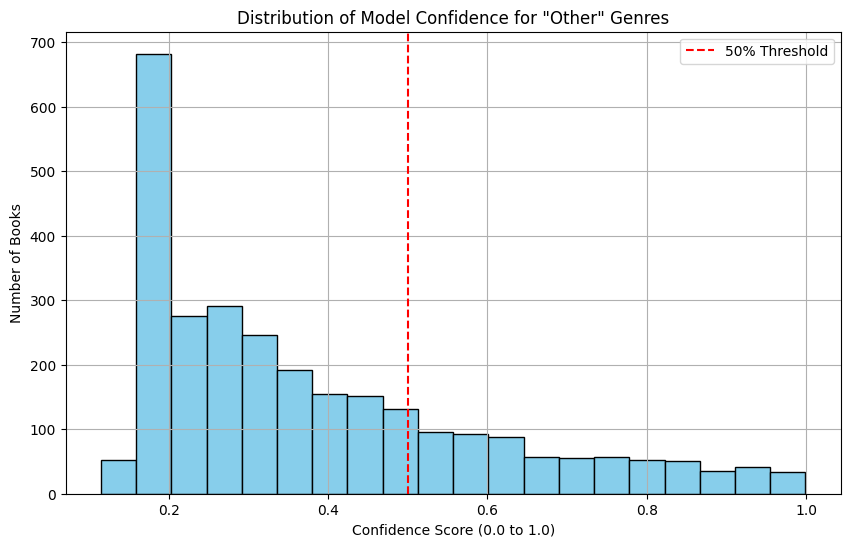

In [274]:
plt.figure(figsize=(10, 6))
books[books['genre_cleaned'] == 'Other']['prediction_confidence'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Model Confidence for "Other" Genres')
plt.xlabel('Confidence Score (0.0 to 1.0)')
plt.ylabel('Number of Books')
plt.axvline(x=0.5, color='red', linestyle='--', label='50% Threshold')
plt.legend()
plt.show()

In [275]:
#Stats for how many we could fillout successfully 
other_books_df = books[books['genre_cleaned'] == 'Other']
total_other = len(other_books_df)

high_confidence_count = len(other_books_df[other_books_df['prediction_confidence'] > 0.5])
percentage_high_conf = (high_confidence_count / total_other) * 100

print(f"--- Confidence Analysis for 'Other' Genres ---")
print(f"Total 'Other' books to predict:      {total_other}")
print(f"Predicted with > 50% confidence:   {high_confidence_count}")
print(f"Percentage of 'Other' successfully filled: {percentage_high_conf:.2f}%")

avg_conf = other_books_df['prediction_confidence'].mean()
print(f"Average confidence score:           {avg_conf:.2f}")

--- Confidence Analysis for 'Other' Genres ---
Total 'Other' books to predict:      2837
Predicted with > 50% confidence:   707
Percentage of 'Other' successfully filled: 24.92%
Average confidence score:           0.38


[Back to top](#-Index)

### Modeling - Recommendations system

 Identify an appropriate classification or regression ML model to utilize as baseline for your analysis.

In [276]:
print (books.info())

<class 'pandas.core.frame.DataFrame'>
Index: 52193 entries, 0 to 52198
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        52193 non-null  object 
 1   link                         52193 non-null  object 
 2   series                       23318 non-null  object 
 3   author                       52193 non-null  object 
 4   author_link                  52193 non-null  object 
 5   rating_count                 52193 non-null  int64  
 6   review_count                 52193 non-null  int64  
 7   average_rating               52193 non-null  float64
 8   five_star_ratings            52193 non-null  int64  
 9   four_star_ratings            52193 non-null  int64  
 10  three_star_ratings           52193 non-null  int64  
 11  two_star_ratings             52193 non-null  int64  
 12  one_star_ratings             52193 non-null  int64  
 13  number_of_pages      

In [277]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Prepare the "Content Soup"
# We combine the most important text features into one string per book
def create_soup(x):
    return f"{x['author']} {x['final_genre']} {x['secondary_genre']} {str(x['description'])[:500]}"

books['soup'] = books.apply(create_soup, axis=1)

# 2. Vectorize the Soup
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(books['soup'])

# 3. Compute Similarity (using a subset or linear_kernel for speed)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 4. The Recommendation Function
def get_recommendations(title, cosine_sim=cosine_sim):
    # Get index of the book
    if title not in books['title'].values:
        return "Book not found."
    
    idx = books[books['title'] == title].index[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 50 candidates (to allow for re-ranking)
    candidate_indices = [i[0] for i in sim_scores[1:51]]
    candidates = books.iloc[candidate_indices].copy()

    # RE-RANKING: Boost books with high ratings and high counts
    # This prevents recommending a similar book that has a 2.0 rating
    candidates['score'] = candidates['average_rating'] * (candidates['rating_count'] > 1000)
    
    return candidates.sort_values('score', ascending=False)[['title', 'author', 'final_genre', 'average_rating']].head(10)

# Example:
# print(get_recommendations("The Hobbit"))

In [278]:
print(get_recommendations("The Book Thief"))

                                                   title              author                    final_genre  average_rating
51289  Looking for Alaska / An Abundance of Katherine...          John Green                    Young Adult            4.50
24800                            The John Green eSampler          John Green                        Fiction            4.46
43443                         The Miracle of Forgiveness  Spencer W. Kimball                       Religion            4.36
22759   When the Body Says No: The Cost of Hidden Stress           Gabor Mat                     Nonfiction            4.31
42341                                         Small Gods     Terry Pratchett                        Fiction            4.30
3030                                      Before I Break        Portia Moore                        Romance            4.27
43599                                               Fear       Michael Grant                    Young Adult            4.24
41526   

In [ ]:
# Quick Validation Logic
target_book = "The Hunger Games"
actual_recommendations = books[books['title'] == target_book]['recommended_books'].values[0]
my_recommendations = get_recommendations(target_book)

print (actual_recommendations)
print (my_recommendations)

# Check how many of 'my_recommendations' IDs appear in 'actual_recommendations'

13335037, 13335037, 41865, 3, 11870085, 28187, 6186357, 10818853, 4671, 3636, 2657, 5907, 256683, 4667024, 960, 1885, 17157681, 11735983, 19288043
                                                   title                                    author                    final_genre  average_rating
25770                                                 -                                      Kalki  Historical-Historical Fiction            4.71
1559                                         Other Title                       Guram Dochanashvili            Historical-Georgian            4.71
44204                                        Other Title                                     Kalki  Historical-Historical Fiction            4.70
24294                                                 -                                      Kalki  Historical-Historical Fiction            4.69
52095                                            Refugee                                Alan Gratz  Historical-Historical F